# Lab Assignment Six: Convolutional Network Architectures

In this lab, we will select a prediction task to perform on our dataset, evaluate a deep learning architecture and tune hyper-parameters.

## Team Members:
1) Mohammed Ahmed Abdelrazek Aboelela.

2) Naim Barnett

## Dataset Selection

Data Set : Intel Image Classification - https://www.kaggle.com/datasets/puneet6060/intel-image-classification?select=seg_test

### Overview and Business Understanding

This dataset is imported from kaggle via this link (https://www.kaggle.com/datasets/puneet6060/intel-image-classification?select=seg_test). It is a very convenient dataset for our purposes as it contains around 25,000 images of size 150x150 distributed under 6 categories {'buildings' -> 0, 'forest' -> 1, 'glacier' -> 2, 'mountain' -> 3, 'sea' -> 4, 'street' -> 5 }, therefore it satisfies the requirements for this lab. It also has a well defined prediction task which is to classify the images into one of the 6 categories we defined.

For a more detailed description of the dataset, The 25,000 is distributed among three different folders, (train, test, and prediction). For our purposes, we will mainly focus on the images in the (train) folder, their number is 14034 images. In the (train) folder, we have six folders, a folder for each category of our six categories and each one of these folders has many images of the respective category with different orientations and shapes. Moreover, the each of the images is of the (RGB) type, thus having 3 channels per pixel, and we have 150 x 150 = 22500 pixels.

It is worth noting that I relied heavily on the professor's notebook, so everything I took from there will be cited with "(Inspired by the professor's notebook)" beforehand.

# Preparation

In [20]:
"""Loading the images data"""
import numpy as np
from matplotlib import image as img
from matplotlib import pyplot as plt
import os
import cv2
from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#Creating labels and containers for the training and test data
class_names = {'buildings' :0,'forest' : 1, 'glacier' : 2, 'mountain' : 3, 'sea' : 4, 'street' : 5 }
X_train = []
y_train = []
X_test = []
y_test = []
img_wh = 150       #image dimensions (chosen so that the image appears clear)
NUM_CLASSES = 6    #The number of different categories of images we have

# a loop that reads the images from the data folder, stores them into their respective train and test containers
for name in class_names:
    directory = 'Lab_2_Dataset/seg_train/seg_train/' + name + '/' 
    for file in os.listdir(directory):
        path = os.path.join(directory, file)
        image = cv2.imread(path)
        image = cv2.resize(image,(img_wh,img_wh))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#       (R,G,B) = cv2.split(image)            for dealing with three channels and splitting them
        i = image.flatten()
        X_train.append(i)
        y_train.append(class_names[name])
    directory = 'Lab_2_Dataset/seg_test/seg_test/' + name + '/' 
    for file in os.listdir(directory):
        path = os.path.join(directory, file)
        image = cv2.imread(path)
        image = cv2.resize(image,(img_wh,img_wh))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#       (R,G,B) = cv2.split(image)            for dealing with three channels and splitting them
        i = image.flatten()
        X_test.append(i)
        y_test.append(class_names[name])

#Shuffeling the images in the containers as they are retrieved class by class as shown in the for loop
X_train, y_train = shuffle(X_train,y_train,random_state=0)
X_test, y_test= shuffle(X_test,y_test,random_state=0)

#Converting our containers into numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

print("A visualization of the table of 1-D image features (each row = one image):")
print(X_train)
print('The shape of the training set: ' + str(X_train.shape))
print('The shape of the testing set: ' + str(X_test.shape))

A visualization of the table of 1-D image features (each row = one image):
[[151 153 155 ...  71  65  16]
 [212 210 210 ... 155 136 141]
 [224 220 225 ...  92 108  67]
 ...
 [124 124 125 ... 102  76  94]
 [ 61  64  68 ...  74  51  25]
 [108  80  58 ...  60 176 114]]
The shape of the training set: (14034, 22500)
The shape of the testing set: (3000, 22500)


In [21]:
from sklearn import metrics as mt
from matplotlib import pyplot as plt
from skimage.io import imshow
import seaborn as sns
%matplotlib inline

# define class to use for NN visualization
labels = ['buildings','forest', 'glacier', 'mountain', 'sea', 'street']
def summarize_net(net, X_test, y_test, title_text=''):
    plt.figure(figsize=(15,5))
    yhat = np.argmax(net.predict(X_test), axis=1)
    acc = mt.accuracy_score(y_test,yhat)
    cm = mt.confusion_matrix(y_test,yhat)
    cm = cm/np.sum(cm,axis=1)[:,np.newaxis]
    sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=labels,yticklabels=labels)
    plt.title(title_text+'{:.4f}'.format(acc))
    

In [22]:
"""Visualizing some data instances we have"""
# function to return key for any value
def get_key(val):
    for key, value in class_names.items():
        if val == value:
            return key

# a helper plotting function (Inspired by the professor's notebook)
def plot_gallery(images, titles, n_row=3, n_col=6):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(3 * n_col, 3 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((img_wh,img_wh,1)))
        plt.title(get_key(titles[i]), size=16)
        plt.xticks(())
        plt.yticks(())

Some of the training data:


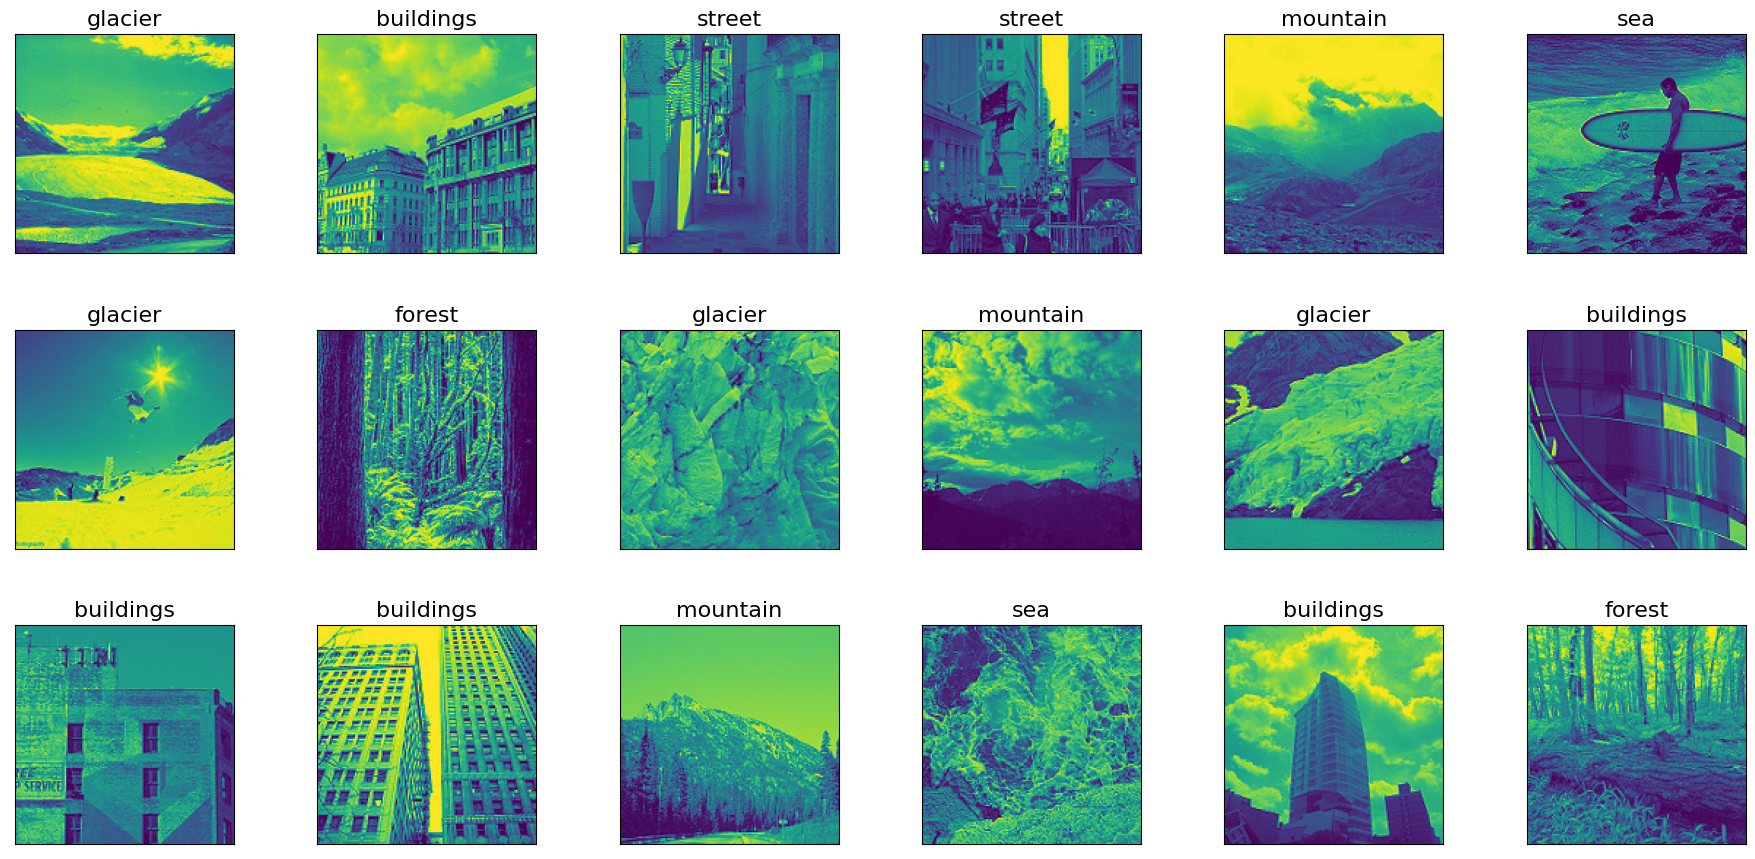

In [23]:
#Plotting some of the training data
print("Some of the training data:")
plot_gallery(X_train, y_train)

Some of the testing data:


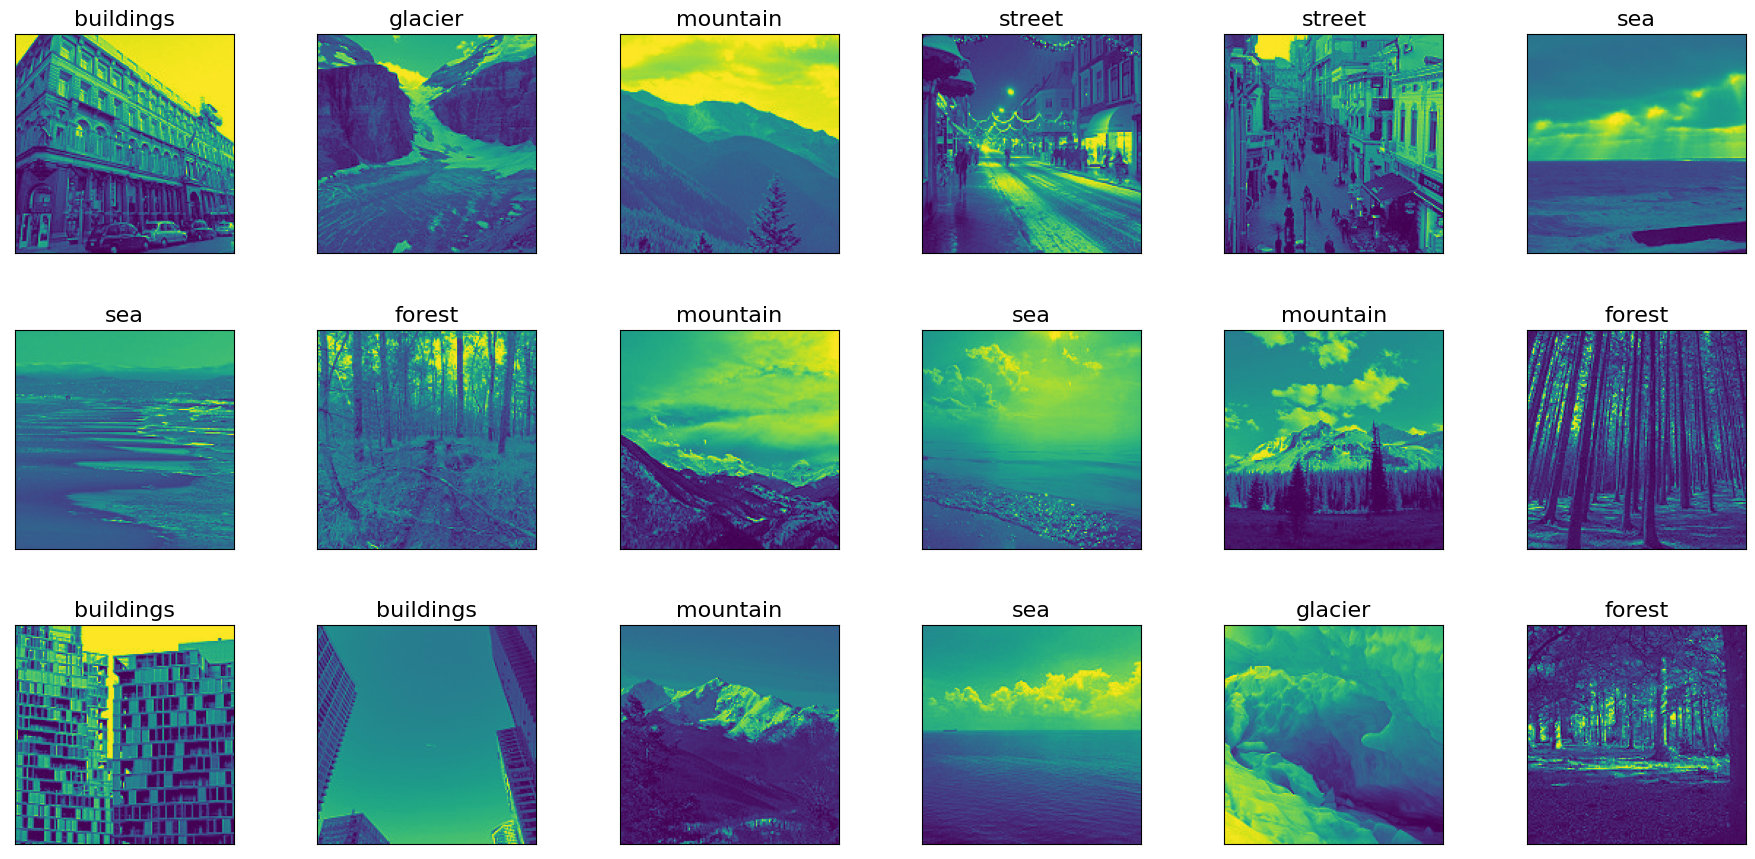

In [24]:
#Plotting some of the testing data
print("Some of the testing data:")
plot_gallery(X_test, y_test)

## Choose and explain what metric(s) you will use to evaluate your algorithm’s performance. You should give a detailed argument for why this (these) metric(s) are appropriate on your data. That is, why is the metric appropriate for the task (e.g., in terms of the business case for the task). Please note: rarely is accuracy the best evaluation metric to use. Think deeply about an appropriate measure of performance.

Third parties (like image search engines) would be really interested in our algorithm to be able to initially have a classifier that tells them whether a provided image falls under one of the 6 categories. The number of categories can also be expanded by including images from other classes and make the prediction task more and more inclusive of more relevant third parties. This data is really important because it is through which the machine can learn the different ways the image of a certain category can exist, the number of ways the pictures are taken, the different types of (buildings, forests, ...etc!) included can be very helpful in having a very powerful algorithm that can capture even the most unclear building/forests/..etc! image. Therefore, the sole judge of the efficiency of our algorithm is whether it well be able to predict data's classes with hidden labels correctly or not, and to which extent, of course, having the maximum efficiency in this regard is what only can be considered as a useful algorithm for third parties. Thus, an algorithm that predicts the correct label 80% of the time is always better than one that does it 60% of the time, and so on. Moreover, having a false positive or a false negative is equally unfavorable. Consequently, this is probably one of the rare casese when "accuracy" will be considered a good performance metric for our purposes.

## Choose the method you will use for dividing your data into training and testing (i.e., are you using Stratified 10-fold cross validation? Shuffle splits? Why?). Explain why your chosen method is appropriate or use more than one method as appropriate. Convince me that your cross validation method is a realistic mirroring of how an algorithm would be used in practice. 

In [25]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5]),
 array([2191, 2271, 2404, 2512, 2274, 2382], dtype=int64))

Looking into the number of instances in the training set (14034 instances) and their distribution among different classes, we can see that there is no drastic difference between the number of each class compared to the others, more or less, they all exist in the same ratio. Thus, since we have the nearly-balanced data, we might be compelled to use shuffle splits with less number of splits than 10 to be more computationally efficient. However, we also need the splits to be stratified to make sure we are mirorring the shape of the original training set. Thus, we decide to go on with using sklearn's StratifiedShuffleSplit.

In [26]:
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=5, test_size=0.5, random_state=0)
print(sss)

StratifiedShuffleSplit(n_splits=5, random_state=0, test_size=0.5,
            train_size=None)


# Modeling

## Setup the training to use data expansion in Keras. Explain why the chosen data expansion techniques are appropriate for your dataset. You can use the keras fit generator as a pre-processing step OR in the optimization loop.

In [27]:
"""Importing the needed packages for this part"""
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Reshape, Input
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import average 
from tensorflow.keras.models import  Model
from sklearn import metrics as mt
from skimage.io import imshow
import struct
import seaborn as sns
%matplotlib inline

In [28]:
"""Inspired by the professor's notebook"""
#fixing the sizes, channels last
X_train = np.expand_dims(X_train.reshape((-1,img_wh,img_wh)), axis=3)
X_test = np.expand_dims(X_test.reshape((-1,img_wh,img_wh)), axis=3)
# the image data has been resized to (samples,image_rows,image_cols,image_channels)

# and one hot encoding the output values
y_train_ohe = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_ohe = keras.utils.to_categorical(y_test, NUM_CLASSES)

print('New Shape: Rows: %d, image size: (%d,%d,%d)' % (X_train.shape[0], X_train.shape[1], X_train.shape[2], X_train.shape[3] ))


New Shape: Rows: 14034, image size: (150,150,1)


(14034, 150, 150, 1)


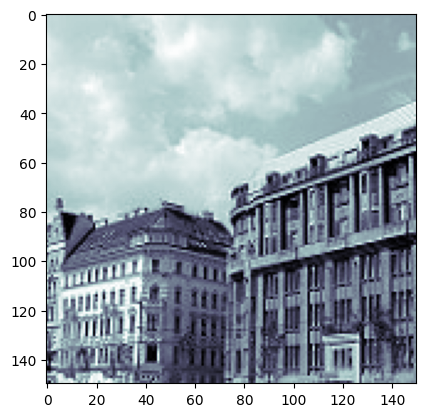

In [29]:
#Visualizing an example output
print(X_train.shape)
plt.subplot(1,1,1)
plt.imshow(X_train[1].squeeze(),cmap='bone')
plt.show()

In [30]:
#Defining the image data generator
datagen = ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=5, # used, Int. Degree range for random rotations.
    width_shift_range=0.1, # used, Float (fraction of total width). Range for random horizontal shifts.
    height_shift_range=0.1, # used,  Float (fraction of total height). Range for random vertical shifts.
    shear_range=0., # Float. Shear Intensity (Shear angle in counter-clockwise direction as radians)
    zoom_range=0.,
    channel_shift_range=0.,
    fill_mode='nearest',
    cval=0.,
    horizontal_flip=True,
    vertical_flip=False,
    rescale=None)

datagen.fit(X_train)

C:\Users\naimb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\skimage\io\_plugins\matplotlib_plugin.py:150: UserWarning: Float image out of standard range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


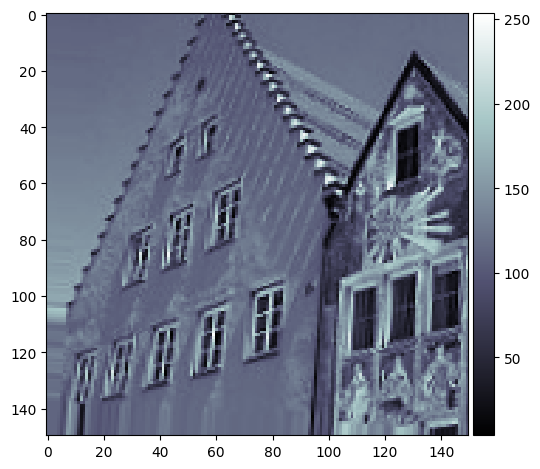

In [31]:
tmps = datagen.flow(X_train, y_train_ohe, batch_size=1)

for tmp in tmps:
    imshow(tmp[0].squeeze(),cmap='bone')
    break

Let's initialize the first convolutional network with an AlexNet style convolutional phase.

In [32]:
img_wh = 150
cnn = Sequential()

cnn.add(Conv2D(filters=32,
                input_shape = (img_wh,img_wh,1),
                kernel_size=(3,3), 
                padding='same', 
                activation='relu', data_format="channels_last")) # more compact syntax

# no max pool before next conv layer!!
cnn.add(Conv2D(filters=64,
                kernel_size=(3,3), 
                padding='same', 
                activation='relu')) # more compact syntax
cnn.add(MaxPooling2D(pool_size=(2, 2), data_format="channels_last"))
    

# add one layer on flattened output
cnn.add(Dropout(0.25)) # add some dropout for regularization after conv layers
cnn.add(Flatten())
cnn.add(Dense(128, activation='relu'))
cnn.add(Dropout(0.5)) # add some dropout for regularization, again!
cnn.add(Dense(NUM_CLASSES, activation='softmax'))

# Let's train the model 
cnn.compile(loss='categorical_crossentropy', # 'categorical_crossentropy' 'mean_squared_error'
              optimizer='rmsprop', # 'adadelta' 'rmsprop'
              metrics=['accuracy'])

# the flow method yields batches of images indefinitely, with the given transformations
cnn.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128), 
                   steps_per_epoch=int(len(X_train)/128), # how many generators to go through per epoch
                   epochs=5, verbose=1,
                   validation_data=(X_test,y_test_ohe)
)

C:\Users\naimb\AppData\Local\Temp\ipykernel_19924\1159379555.py:31: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  cnn.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128),


Epoch 1/5
109/109 [==============================] - 500s 5s/step - loss: 185.6329 - accuracy: 0.1796 - val_loss: 1.7912 - val_accuracy: 0.1750
Epoch 2/5
109/109 [==============================] - 504s 5s/step - loss: 4.4647 - accuracy: 0.2136 - val_loss: 1.7842 - val_accuracy: 0.1630
Epoch 3/5
109/109 [==============================] - 500s 5s/step - loss: 1.9369 - accuracy: 0.2283 - val_loss: 1.7601 - val_accuracy: 0.2483
Epoch 4/5
109/109 [==============================] - 498s 5s/step - loss: 1.9030 - accuracy: 0.2487 - val_loss: 1.4025 - val_accuracy: 0.3407
Epoch 5/5
109/109 [==============================] - 496s 5s/step - loss: 2.4494 - accuracy: 0.2085 - val_loss: 1.7965 - val_accuracy: 0.1667


94/94 [==============================] - 29s 303ms/step


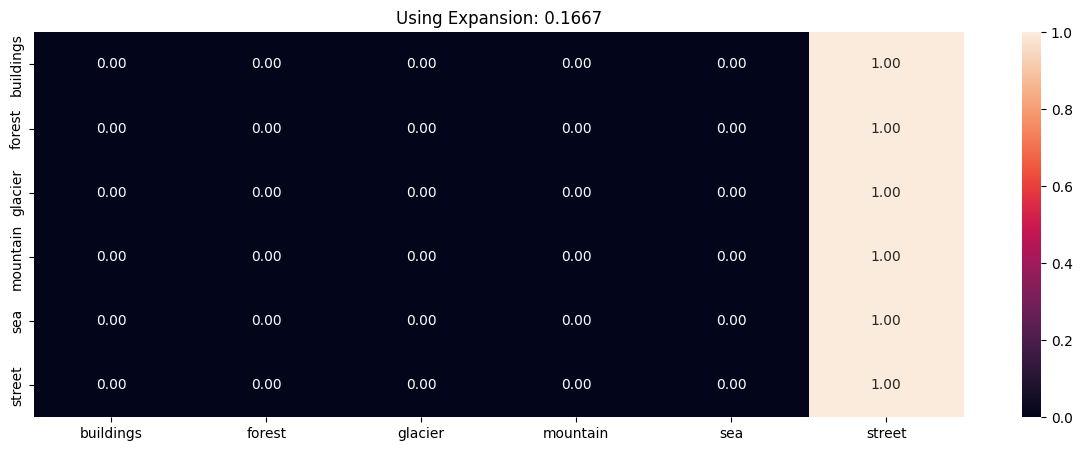

In [61]:
summarize_net(cnn, X_test, y_test, title_text='Using Expansion: ')

In [65]:
! pip install scikeras

In [69]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score
from scikeras.wrappers import KerasClassifier

model = KerasClassifier(model=cnn, epochs=5, batch_size=10, verbose=0)
my_scorer = make_scorer(accuracy_score)
results = cross_val_score(model, X_test, y_test_ohe, cv=sss, scoring=my_scorer)
print(results.mean())

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmprb4xe5mr\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmprb4xe5mr\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpn63cme0h\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpn63cme0h\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpecb26b3n\assets


...

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp6mq81_yj\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp6mq81_yj\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpvvi3wzq5\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpvvi3wzq5\assets


0.18453333333333335


The model is currently only able to predict 'mountain". Let's decrease the kernal size and see the results.

In [34]:
cnn2 = Sequential()

# let's start with an AlexNet style convolutional phase
cnn2.add(Conv2D(filters=32,
                input_shape = (img_wh,img_wh,1),
                kernel_size=(2,2), 
                padding='same', 
                activation='relu', data_format="channels_last")) # more compact syntax

# no max pool before next conv layer!!
cnn2.add(Conv2D(filters=64,
                kernel_size=(2,2), 
                padding='same', 
                activation='relu')) # more compact syntax
cnn2.add(MaxPooling2D(pool_size=(2, 2), data_format="channels_last"))
    

# add one layer on flattened output
cnn2.add(Dropout(0.25)) # add some dropout for regularization after conv layers
cnn2.add(Flatten())
cnn2.add(Dense(128, activation='relu'))
cnn2.add(Dropout(0.5)) # add some dropout for regularization, again!
cnn2.add(Dense(NUM_CLASSES, activation='softmax'))

# Let's train the model 
cnn2.compile(loss='categorical_crossentropy', # 'categorical_crossentropy' 'mean_squared_error'
              optimizer='rmsprop', # 'adadelta' 'rmsprop'
              metrics=['accuracy'])

# the flow method yields batches of images indefinitely, with the given transformations
cnn2.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128), 
                   steps_per_epoch=int(len(X_train)/128), # how many generators to go through per epoch
                   epochs=5, verbose=1,
                   validation_data=(X_test,y_test_ohe)
)

C:\Users\naimb\AppData\Local\Temp\ipykernel_19924\1939342057.py:31: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  cnn2.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128),


Epoch 1/5
109/109 [==============================] - 352s 3s/step - loss: 112.4865 - accuracy: 0.1796 - val_loss: 1.7895 - val_accuracy: 0.1767
Epoch 2/5
109/109 [==============================] - 351s 3s/step - loss: 4.0592 - accuracy: 0.1788 - val_loss: 1.7908 - val_accuracy: 0.1750
Epoch 3/5
109/109 [==============================] - 351s 3s/step - loss: 2.1296 - accuracy: 0.1783 - val_loss: 39.5530 - val_accuracy: 0.1750
Epoch 4/5
109/109 [==============================] - 351s 3s/step - loss: 2.3452 - accuracy: 0.1788 - val_loss: 1.7888 - val_accuracy: 0.1763
Epoch 5/5
109/109 [==============================] - 391s 4s/step - loss: 1.8355 - accuracy: 0.1782 - val_loss: 1.7903 - val_accuracy: 0.1750


94/94 [==============================] - 19s 203ms/step


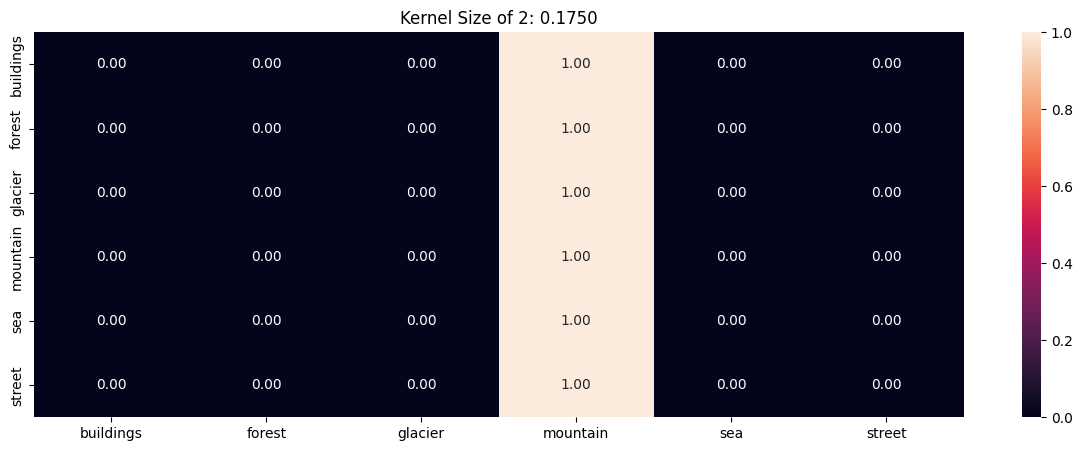

In [60]:
summarize_net(cnn2, X_test, y_test, title_text='Kernel Size of 2: ')

In [73]:
model = KerasClassifier(model=cnn2, epochs=5, batch_size=10, verbose=0)
my_scorer = make_scorer(accuracy_score)
results = cross_val_score(model, X_test, y_test_ohe, cv=sss, scoring=my_scorer)
print(results.mean())

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpkkz6c1qn\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpkkz6c1qn\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpgf3h0q_3\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpgf3h0q_3\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpz26vr_81\assets


...

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpe3gl564v\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpe3gl564v\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmple67wfw_\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmple67wfw_\assets


0.18453333333333335


Still fairly the same results. Let's try increasing the kernal size. 

In [36]:
cnn3 = Sequential()

# let's start with an AlexNet style convolutional phase
cnn3.add(Conv2D(filters=32,
                input_shape = (img_wh,img_wh,1),
                kernel_size=(4,4), 
                padding='same', 
                activation='relu', data_format="channels_last")) # more compact syntax

# no max pool before next conv layer!!
cnn3.add(Conv2D(filters=64,
                kernel_size=(4,4), 
                padding='same', 
                activation='relu')) # more compact syntax
cnn3.add(MaxPooling2D(pool_size=(2, 2), data_format="channels_last"))
    

# add one layer on flattened output
cnn3.add(Dropout(0.25)) # add some dropout for regularization after conv layers
cnn3.add(Flatten())
cnn3.add(Dense(128, activation='relu'))
cnn3.add(Dropout(0.5)) # add some dropout for regularization, again!
cnn3.add(Dense(NUM_CLASSES, activation='softmax'))

# Let's train the model 
cnn3.compile(loss='categorical_crossentropy', # 'categorical_crossentropy' 'mean_squared_error'
              optimizer='rmsprop', # 'adadelta' 'rmsprop'
              metrics=['accuracy'])

# the flow method yields batches of images indefinitely, with the given transformations
cnn3.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128), 
                   steps_per_epoch=int(len(X_train)/128), # how many generators to go through per epoch
                   epochs=5, verbose=1,
                   validation_data=(X_test,y_test_ohe)
)

C:\Users\naimb\AppData\Local\Temp\ipykernel_19924\395905551.py:31: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  cnn3.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128),


Epoch 1/5
109/109 [==============================] - 757s 7s/step - loss: 35.2619 - accuracy: 0.2946 - val_loss: 1.6448 - val_accuracy: 0.3737
Epoch 2/5
109/109 [==============================] - 758s 7s/step - loss: 4.1131 - accuracy: 0.2911 - val_loss: 1.5475 - val_accuracy: 0.3853
Epoch 3/5
109/109 [==============================] - 752s 7s/step - loss: 2.2773 - accuracy: 0.3199 - val_loss: 1.3866 - val_accuracy: 0.4313
Epoch 4/5
109/109 [==============================] - 678s 6s/step - loss: 1.7956 - accuracy: 0.3363 - val_loss: 1.3938 - val_accuracy: 0.4390
Epoch 5/5
109/109 [==============================] - 719s 7s/step - loss: 1.6324 - accuracy: 0.3766 - val_loss: 1.2898 - val_accuracy: 0.5013


94/94 [==============================] - 41s 435ms/step


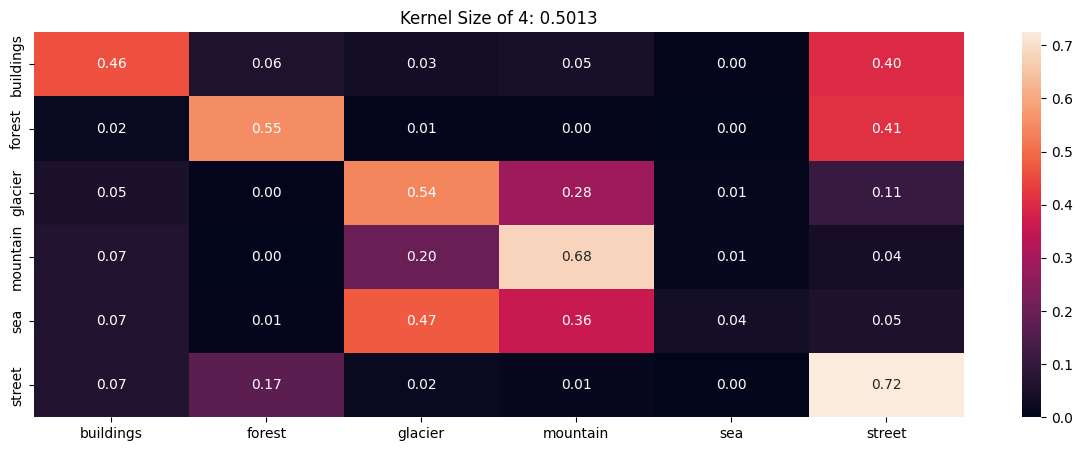

In [59]:
summarize_net(cnn3, X_test, y_test, title_text='Kernel Size of 4: ')

In [75]:
model = KerasClassifier(model=cnn3, epochs=5, batch_size=10, verbose=0)
my_scorer = make_scorer(accuracy_score)
results = cross_val_score(model, X_test, y_test_ohe, cv=sss, scoring=my_scorer)
print(results.mean())

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp9f7xsdax\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp9f7xsdax\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp5bwgzww7\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp5bwgzww7\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpo3omr7sv\assets


...

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpd8bbejk9\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpd8bbejk9\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpzvgxr046\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpzvgxr046\assets


0.4431999999999999


The model seems to be performing a bit better. Let's increase the kernal one more time.

In [38]:
cnn4 = Sequential()

# let's start with an AlexNet style convolutional phase
cnn4.add(Conv2D(filters=32,
                input_shape = (img_wh,img_wh,1),
                kernel_size=(5,5), 
                padding='same', 
                activation='relu', data_format="channels_last")) # more compact syntax

# no max pool before next conv layer!!
cnn4.add(Conv2D(filters=64,
                kernel_size=(5,5), 
                padding='same', 
                activation='relu')) # more compact syntax
cnn4.add(MaxPooling2D(pool_size=(2, 2), data_format="channels_last"))
    

# add one layer on flattened output
cnn4.add(Dropout(0.25)) # add some dropout for regularization after conv layers
cnn4.add(Flatten())
cnn4.add(Dense(128, activation='relu'))
cnn4.add(Dropout(0.5)) # add some dropout for regularization, again!
cnn4.add(Dense(NUM_CLASSES, activation='softmax'))

# Let's train the model 
cnn4.compile(loss='categorical_crossentropy', # 'categorical_crossentropy' 'mean_squared_error'
              optimizer='rmsprop', # 'adadelta' 'rmsprop'
              metrics=['accuracy'])

# the flow method yields batches of images indefinitely, with the given transformations
cnn4.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128), 
                   steps_per_epoch=int(len(X_train)/128), # how many generators to go through per epoch
                   epochs=5, verbose=1,
                   validation_data=(X_test,y_test_ohe)
)

C:\Users\naimb\AppData\Local\Temp\ipykernel_19924\3014685922.py:31: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  cnn4.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128),


Epoch 1/5
109/109 [==============================] - 1011s 9s/step - loss: 141.1287 - accuracy: 0.2752 - val_loss: 1.6625 - val_accuracy: 0.2723
Epoch 2/5
109/109 [==============================] - 971s 9s/step - loss: 7.6277 - accuracy: 0.2952 - val_loss: 4.0488 - val_accuracy: 0.1923
Epoch 3/5
109/109 [==============================] - 938s 9s/step - loss: 10.1210 - accuracy: 0.2057 - val_loss: 1.7900 - val_accuracy: 0.1750
Epoch 4/5
109/109 [==============================] - 1077s 10s/step - loss: 1.7924 - accuracy: 0.1791 - val_loss: 1.7901 - val_accuracy: 0.1753
Epoch 5/5
109/109 [==============================] - 1171s 11s/step - loss: 2.7916 - accuracy: 0.1791 - val_loss: 1.7902 - val_accuracy: 0.1753


94/94 [==============================] - 60s 635ms/step


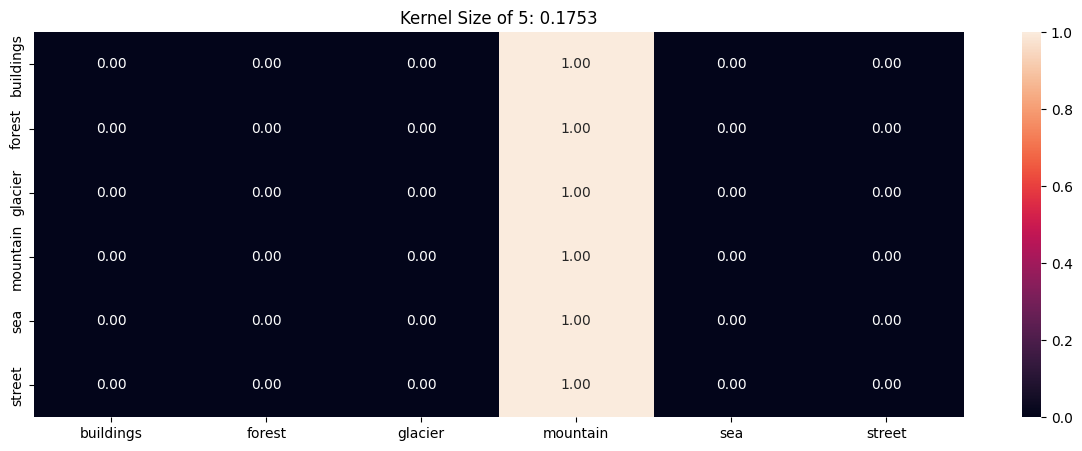

In [58]:
summarize_net(cnn4, X_test, y_test, title_text='Kernel Size of 5: ')

In [74]:
model = KerasClassifier(model=cnn4, epochs=5, batch_size=10, verbose=0)
my_scorer = make_scorer(accuracy_score)
results = cross_val_score(model, X_test, y_test_ohe, cv=sss, scoring=my_scorer)
print(results.mean())

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpxrjonsgc\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpxrjonsgc\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp6sxzbonk\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp6sxzbonk\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp_givlbq3\assets


...

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpa4oyty_k\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpa4oyty_k\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpdgla9i8d\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpdgla9i8d\assets


0.18466666666666667


Let's now test teh convolutional network with both layers having 32 filters.

In [40]:
cnn5 = Sequential()

# let's start with an AlexNet style convolutional phase
cnn5.add(Conv2D(filters=32,
                input_shape = (img_wh,img_wh,1),
                kernel_size=(5,5), 
                padding='same', 
                activation='relu', data_format="channels_last")) # more compact syntax

# no max pool before next conv layer!!
cnn5.add(Conv2D(filters=32,
                kernel_size=(5,5), 
                padding='same', 
                activation='relu')) # more compact syntax
cnn5.add(MaxPooling2D(pool_size=(2, 2), data_format="channels_last"))
    

# add one layer on flattened output
cnn5.add(Dropout(0.25)) # add some dropout for regularization after conv layers
cnn5.add(Flatten())
cnn5.add(Dense(128, activation='relu'))
cnn5.add(Dropout(0.5)) # add some dropout for regularization, again!
cnn5.add(Dense(NUM_CLASSES, activation='softmax'))

# Let's train the model 
cnn5.compile(loss='categorical_crossentropy', # 'categorical_crossentropy' 'mean_squared_error'
              optimizer='rmsprop', # 'adadelta' 'rmsprop'
              metrics=['accuracy'])

# the flow method yields batches of images indefinitely, with the given transformations
cnn5.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128), 
                   steps_per_epoch=int(len(X_train)/128), # how many generators to go through per epoch
                   epochs=5, verbose=1,
                   validation_data=(X_test,y_test_ohe)
)

C:\Users\naimb\AppData\Local\Temp\ipykernel_19924\2920599783.py:31: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  cnn5.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128),


Epoch 1/5
109/109 [==============================] - 846s 8s/step - loss: 20.1514 - accuracy: 0.2698 - val_loss: 1.8925 - val_accuracy: 0.1703
Epoch 2/5
109/109 [==============================] - 818s 8s/step - loss: 2.1808 - accuracy: 0.2944 - val_loss: 1.4329 - val_accuracy: 0.3877
Epoch 3/5
109/109 [==============================] - 728s 7s/step - loss: 2.1386 - accuracy: 0.2562 - val_loss: 1.7667 - val_accuracy: 0.1710
Epoch 4/5
109/109 [==============================] - 594s 5s/step - loss: 1.9700 - accuracy: 0.1960 - val_loss: 1.7710 - val_accuracy: 0.1970
Epoch 5/5
109/109 [==============================] - 598s 5s/step - loss: 1.8527 - accuracy: 0.2383 - val_loss: 1.5126 - val_accuracy: 0.3080


94/94 [==============================] - 35s 369ms/step


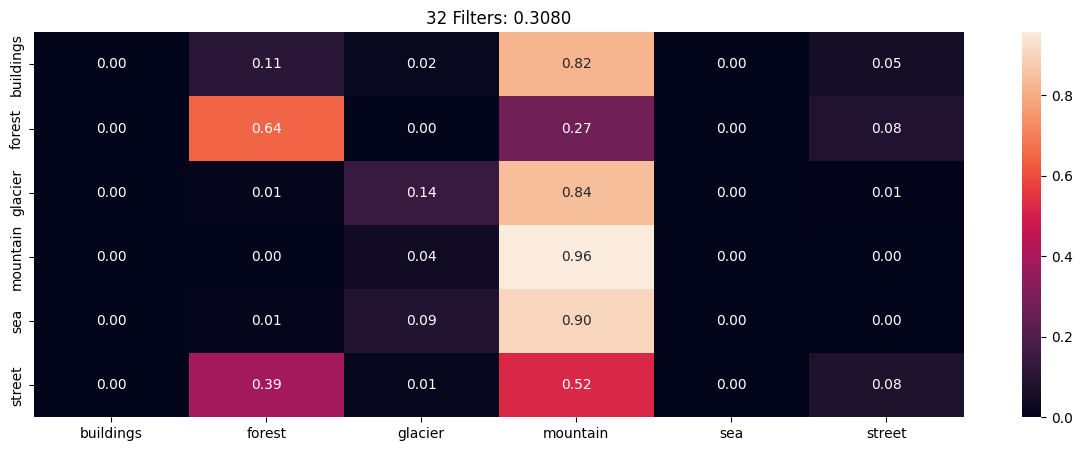

In [57]:
summarize_net(cnn5, X_test, y_test, title_text='32 Filters: ')

In [76]:
model = KerasClassifier(model=cnn5, epochs=5, batch_size=10, verbose=0)
my_scorer = make_scorer(accuracy_score)
results = cross_val_score(model, X_test, y_test_ohe, cv=sss, scoring=my_scorer)
print(results.mean())

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpj259d2_6\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpj259d2_6\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpz4nxx5vq\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpz4nxx5vq\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp0kmh8gyp\assets


...

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpoxdogplp\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpoxdogplp\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpgp1804o0\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpgp1804o0\assets


0.20439999999999997


Now, let's try the a convolutional nextwork with both layers having 64 filters.

In [42]:
cnn6 = Sequential()

# let's start with an AlexNet style convolutional phase
cnn6.add(Conv2D(filters=64,
                input_shape = (img_wh,img_wh,1),
                kernel_size=(5,5), 
                padding='same', 
                activation='relu', data_format="channels_last")) # more compact syntax

# no max pool before next conv layer!!
cnn6.add(Conv2D(filters=64,
                kernel_size=(5,5), 
                padding='same', 
                activation='relu')) # more compact syntax
cnn6.add(MaxPooling2D(pool_size=(2, 2), data_format="channels_last"))
    

# add one layer on flattened output
cnn6.add(Dropout(0.25)) # add some dropout for regularization after conv layers
cnn6.add(Flatten())
cnn6.add(Dense(128, activation='relu'))
cnn6.add(Dropout(0.5)) # add some dropout for regularization, again!
cnn6.add(Dense(NUM_CLASSES, activation='softmax'))

# Let's train the model 
cnn6.compile(loss='categorical_crossentropy', # 'categorical_crossentropy' 'mean_squared_error'
              optimizer='rmsprop', # 'adadelta' 'rmsprop'
              metrics=['accuracy'])

# the flow method yields batches of images indefinitely, with the given transformations
cnn6.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128), 
                   steps_per_epoch=int(len(X_train)/128), # how many generators to go through per epoch
                   epochs=5, verbose=1,
                   validation_data=(X_test,y_test_ohe)
)

C:\Users\naimb\AppData\Local\Temp\ipykernel_19924\3964501116.py:31: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  cnn6.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128),


Epoch 1/5
109/109 [==============================] - 1445s 13s/step - loss: 151.5771 - accuracy: 0.2829 - val_loss: 2.5280 - val_accuracy: 0.1603
Epoch 2/5
109/109 [==============================] - 1446s 13s/step - loss: 43.1233 - accuracy: 0.1905 - val_loss: 1.7905 - val_accuracy: 0.1750
Epoch 3/5
109/109 [==============================] - 1473s 14s/step - loss: 4.4064 - accuracy: 0.1780 - val_loss: 1.7896 - val_accuracy: 0.1753
Epoch 4/5
109/109 [==============================] - 1476s 14s/step - loss: 1.7910 - accuracy: 0.1788 - val_loss: 1.7895 - val_accuracy: 0.1753
Epoch 5/5
109/109 [==============================] - 1459s 13s/step - loss: 1.7908 - accuracy: 0.1793 - val_loss: 1.7895 - val_accuracy: 0.1753


94/94 [==============================] - 102s 1s/step


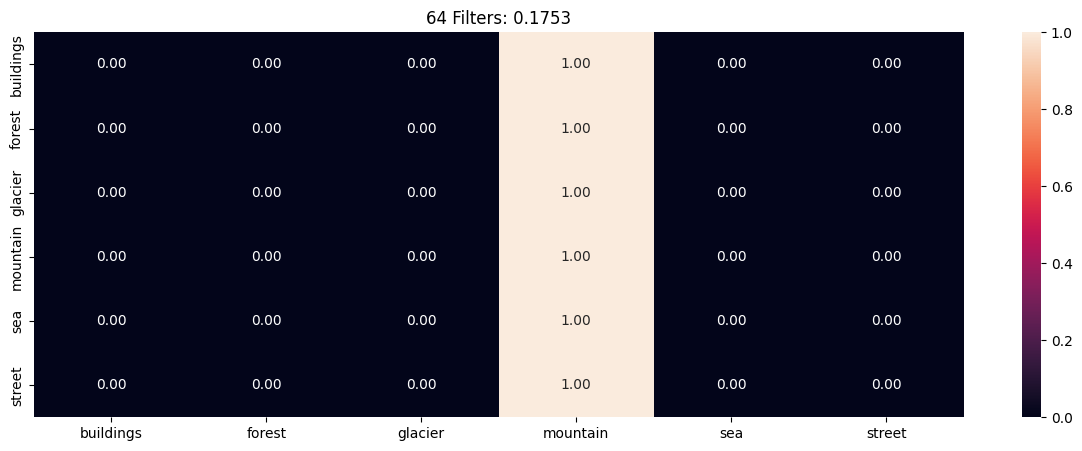

In [56]:
summarize_net(cnn6, X_test, y_test, title_text='64 Filters: ')

In [79]:
model = KerasClassifier(model=cnn6, epochs=5, batch_size=10, verbose=0)
my_scorer = make_scorer(accuracy_score)
results = cross_val_score(model, X_test, y_test_ohe, cv=sss, scoring=my_scorer)
print(results.mean())

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpgil4anay\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpgil4anay\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmprcvkxs0h\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmprcvkxs0h\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpou_db_zm\assets


...

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpcnej1euq\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpcnej1euq\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpvw81kw77\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpvw81kw77\assets


0.18493333333333334


The best results come from a network with 32 filters for both layers and a kernal size of 4. Let's combine these parameters and observe the results.

In [44]:
cnn7 = Sequential()

# let's start with an AlexNet style convolutional phase
cnn7.add(Conv2D(filters=32,
                input_shape = (img_wh,img_wh,1),
                kernel_size=(4,4), 
                padding='same', 
                activation='relu', data_format="channels_last")) # more compact syntax

# no max pool before next conv layer!!
cnn7.add(Conv2D(filters=32,
                kernel_size=(4,4), 
                padding='same', 
                activation='relu')) # more compact syntax
cnn7.add(MaxPooling2D(pool_size=(2, 2), data_format="channels_last"))
    

# add one layer on flattened output
cnn7.add(Dropout(0.25)) # add some dropout for regularization after conv layers
cnn7.add(Flatten())
cnn7.add(Dense(128, activation='relu'))
cnn7.add(Dropout(0.5)) # add some dropout for regularization, again!
cnn7.add(Dense(NUM_CLASSES, activation='softmax'))

# Let's train the model 
cnn7.compile(loss='categorical_crossentropy', # 'categorical_crossentropy' 'mean_squared_error'
              optimizer='rmsprop', # 'adadelta' 'rmsprop'
              metrics=['accuracy'])

# the flow method yields batches of images indefinitely, with the given transformations
cnn7.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128), 
                   steps_per_epoch=int(len(X_train)/128), # how many generators to go through per epoch
                   epochs=5, verbose=1,
                   validation_data=(X_test,y_test_ohe)
)

C:\Users\naimb\AppData\Local\Temp\ipykernel_19924\4119695731.py:31: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  cnn7.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128),


Epoch 1/5
109/109 [==============================] - 426s 4s/step - loss: 28.4100 - accuracy: 0.2774 - val_loss: 1.4994 - val_accuracy: 0.4053
Epoch 2/5
109/109 [==============================] - 431s 4s/step - loss: 1.8421 - accuracy: 0.3586 - val_loss: 1.3482 - val_accuracy: 0.4900
Epoch 3/5
109/109 [==============================] - 430s 4s/step - loss: 1.7483 - accuracy: 0.3998 - val_loss: 1.4586 - val_accuracy: 0.4487
Epoch 4/5
109/109 [==============================] - 432s 4s/step - loss: 2.1026 - accuracy: 0.4335 - val_loss: 1.2037 - val_accuracy: 0.5230
Epoch 5/5
109/109 [==============================] - 429s 4s/step - loss: 1.4624 - accuracy: 0.4477 - val_loss: 1.2080 - val_accuracy: 0.5233


94/94 [==============================] - 29s 313ms/step


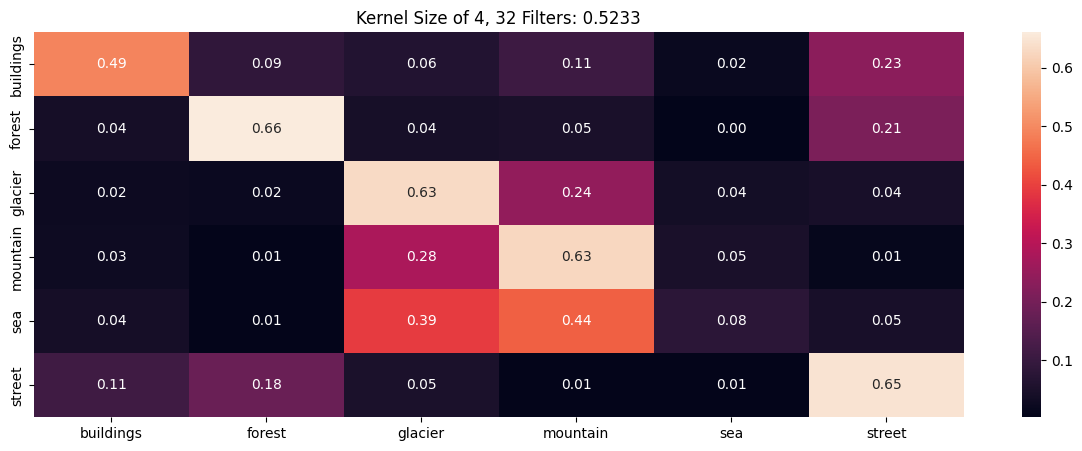

In [55]:
summarize_net(cnn7, X_test, y_test, title_text='Kernel Size of 4, 32 Filters: ')

In [78]:
model = KerasClassifier(model=cnn7, epochs=5, batch_size=10, verbose=0)
my_scorer = make_scorer(accuracy_score)
results = cross_val_score(model, X_test, y_test_ohe, cv=sss, scoring=my_scorer)
print(results.mean())

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp4pelvorc\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp4pelvorc\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpg18fx3v7\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpg18fx3v7\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp2emg2u7v\assets


...

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp3wyq7wxu\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp3wyq7wxu\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp3wxu7kcd\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp3wxu7kcd\assets


0.5017333333333334


Let's now test the results with an additional layer.

In [70]:
cnn8 = Sequential()

# let's start with an AlexNet style convolutional phase
cnn8.add(Conv2D(filters=32,
                input_shape = (img_wh,img_wh,1),
                kernel_size=(4,4), 
                padding='same', 
                activation='relu', data_format="channels_last")) # more compact syntax

# no max pool before next conv layer!!
cnn8.add(Conv2D(filters=32,
                kernel_size=(4,4), 
                padding='same', 
                activation='relu')) # more compact syntax

# no max pool before next conv layer!!
cnn8.add(Conv2D(filters=32,
                kernel_size=(4,4), 
                padding='same', 
                activation='relu')) # more compact syntax
                
cnn8.add(MaxPooling2D(pool_size=(2, 2), data_format="channels_last"))
    

# add one layer on flattened output
cnn8.add(Dropout(0.25)) # add some dropout for regularization after conv layers
cnn8.add(Flatten())
cnn8.add(Dense(128, activation='relu'))
cnn8.add(Dropout(0.5)) # add some dropout for regularization, again!
cnn8.add(Dense(NUM_CLASSES, activation='softmax'))

# Let's train the model 
cnn8.compile(loss='categorical_crossentropy', # 'categorical_crossentropy' 'mean_squared_error'
              optimizer='rmsprop', # 'adadelta' 'rmsprop'
              metrics=['accuracy'])

# the flow method yields batches of images indefinitely, with the given transformations
cnn8.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128), 
                   steps_per_epoch=int(len(X_train)/128), # how many generators to go through per epoch
                   epochs=5, verbose=1,
                   validation_data=(X_test,y_test_ohe)
)

C:\Users\naimb\AppData\Local\Temp\ipykernel_19924\2181387169.py:38: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  cnn8.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128),


Epoch 1/5
109/109 [==============================] - 748s 7s/step - loss: 22.5143 - accuracy: 0.2642 - val_loss: 1.7065 - val_accuracy: 0.2690
Epoch 2/5
109/109 [==============================] - 742s 7s/step - loss: 9.1113 - accuracy: 0.2597 - val_loss: 1.6839 - val_accuracy: 0.2520
Epoch 3/5
109/109 [==============================] - 745s 7s/step - loss: 1.7962 - accuracy: 0.2531 - val_loss: 1.7146 - val_accuracy: 0.3347
Epoch 4/5
109/109 [==============================] - 753s 7s/step - loss: 2.7533 - accuracy: 0.3203 - val_loss: 1.3762 - val_accuracy: 0.3903
Epoch 5/5
109/109 [==============================] - 757s 7s/step - loss: 3.0155 - accuracy: 0.2253 - val_loss: 1.7891 - val_accuracy: 0.1670


94/94 [==============================] - 39s 416ms/step


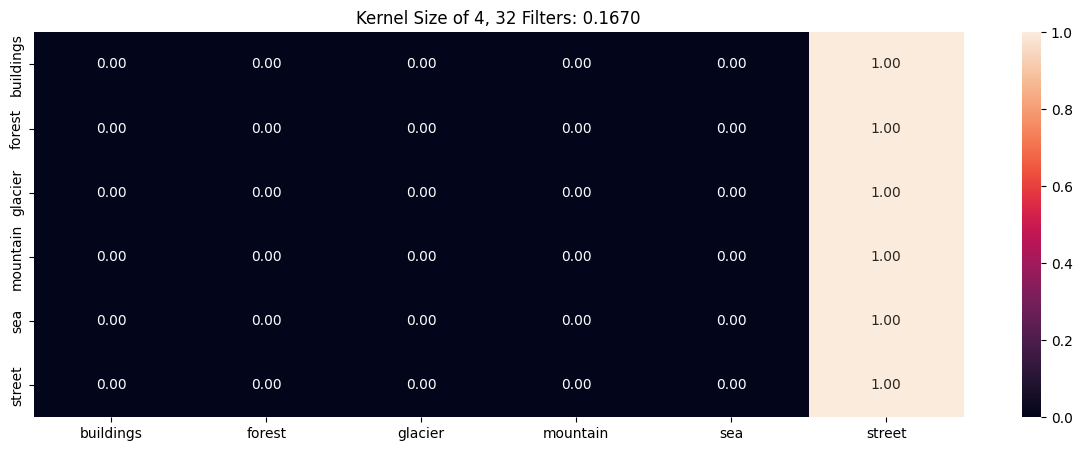

In [71]:
summarize_net(cnn8, X_test, y_test, title_text='Kernel Size of 4, 32 Filters: ')

In [77]:
model = KerasClassifier(model=cnn8, epochs=5, batch_size=10, verbose=0)
my_scorer = make_scorer(accuracy_score)
results = cross_val_score(model, X_test, y_test_ohe, cv=sss, scoring=my_scorer)
print(results.mean())

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpidyhpuyv\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpidyhpuyv\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp68v8wwx2\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp68v8wwx2\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmps47wvx3f\assets


...

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp4ze5n5l3\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp4ze5n5l3\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpy1p6b991\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpy1p6b991\assets


0.3189333333333334


Now, let's implement an ensemble style convolutional network.

In [46]:
from tensorflow.keras.layers import Input, average, concatenate
from tensorflow.keras.models import Model
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Reshape, Input
# from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
# from tensorflow.keras.layers import Conv2D, MaxPooling2D

num_ensembles = 3
l2_lambda = 0.000001

input_holder = Input(shape=(img_wh, img_wh, 1))

# start with a conv layer
x = Conv2D(filters=32,
               input_shape = (img_wh,img_wh,1),
               kernel_size=(4,4),
               kernel_initializer='he_uniform', 
               kernel_regularizer=l2(l2_lambda),
               padding='same', 
               activation='relu', data_format="channels_last")(input_holder)

x = Conv2D(filters=32,
               kernel_size=(4,4),
               kernel_initializer='he_uniform', 
               kernel_regularizer=l2(l2_lambda),
               padding='same', 
               activation='relu')(x)
input_conv = MaxPooling2D(pool_size=(2, 2), data_format="channels_last")(x)

branches = []
for _ in range(num_ensembles):
    
    # start using NiN (MLPConv)
    x = Conv2D(filters=32,
                   input_shape = (img_wh,img_wh,1),
                   kernel_size=(4,4),
                   kernel_initializer='he_uniform', 
                   kernel_regularizer=l2(l2_lambda),
                   padding='same', 
                   activation='linear', data_format="channels_last")(input_conv)

    x = Conv2D(filters=32,
                   kernel_size=(4,4),
                   kernel_initializer='he_uniform', 
                   kernel_regularizer=l2(l2_lambda),
                   padding='same', 
                   activation='relu', data_format="channels_last")(x)
    
    x = MaxPooling2D(pool_size=(2, 2), data_format="channels_last")(x)
    
    x = Conv2D(filters=32,
                   input_shape = (img_wh,img_wh,1),
                   kernel_size=(4,4),
                   kernel_initializer='he_uniform', 
                   kernel_regularizer=l2(l2_lambda),
                   padding='same', 
                   activation='linear', data_format="channels_last")(x)

    x = Conv2D(filters=32,
                   kernel_size=(4,4),
                   kernel_initializer='he_uniform', 
                   kernel_regularizer=l2(l2_lambda),
                   padding='same', 
                   activation='linear', data_format="channels_last")(x)
    
    x = MaxPooling2D(pool_size=(2, 2), data_format="channels_last")(x)

    # add one layer on flattened output
    x = Flatten()(x)
    x = Dropout(0.50)(x) # add some dropout for regularization after conv layers
    x = Dense(64, 
              activation='relu',
              kernel_initializer='he_uniform',
              kernel_regularizer=l2(l2_lambda)
            )(x)
    
    x = Dense(NUM_CLASSES, 
              activation='relu',
              kernel_initializer='he_uniform',
              kernel_regularizer=l2(l2_lambda)
             )(x)
    
    # now add this branch onto the master list
    branches.append(x)

# that's it, we just need to average the results
x = concatenate(branches)

x = Dense(NUM_CLASSES, 
          activation='softmax', 
          kernel_initializer='glorot_uniform',
          kernel_regularizer=l2(l2_lambda)
         )(x)

# here is the secret sauce for setting the network using the 
#   Functional API:
cnn_ens = Model(inputs=input_holder,outputs=x)

cnn_ens.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 150, 150, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_18 (Conv2D)             (None, 150, 150, 32  544         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_19 (Conv2D)             (None, 150, 150, 32  16416       ['conv2d_18[0][0]']              
                                )                                                             

In [47]:
# Let's train the model 
cnn_ens.compile(loss='categorical_crossentropy', # 'categorical_crossentropy' 'mean_squared_error'
                optimizer='adam', # 'adadelta' 'rmsprop'
                metrics=['accuracy'])

In [48]:
# the flow method yields batches of images indefinitely, with the given transofmrations
cnn_ens.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128), 
                      steps_per_epoch=int(len(X_train)/128), # how many generators to go through per epoch
                      epochs=5, verbose=1,
                      validation_data=(X_test,y_test_ohe),
                      callbacks=[EarlyStopping(monitor='val_loss', patience=4)]
                     )

C:\Users\naimb\AppData\Local\Temp\ipykernel_19924\918246403.py:2: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  cnn_ens.fit_generator(datagen.flow(X_train, y_train_ohe, batch_size=128),


Epoch 1/5
109/109 [==============================] - 915s 8s/step - loss: 102.6033 - accuracy: 0.1632 - val_loss: 1.7928 - val_accuracy: 0.1843
Epoch 2/5
109/109 [==============================] - 909s 8s/step - loss: 1.7929 - accuracy: 0.1705 - val_loss: 1.7922 - val_accuracy: 0.1843
Epoch 3/5
109/109 [==============================] - 916s 8s/step - loss: 1.7926 - accuracy: 0.1762 - val_loss: 1.7919 - val_accuracy: 0.1750
Epoch 4/5
109/109 [==============================] - 999s 9s/step - loss: 1.7924 - accuracy: 0.1793 - val_loss: 1.7917 - val_accuracy: 0.1750
Epoch 5/5
109/109 [==============================] - 1059s 10s/step - loss: 1.7923 - accuracy: 0.1793 - val_loss: 1.7916 - val_accuracy: 0.1750


94/94 [==============================] - 54s 570ms/step


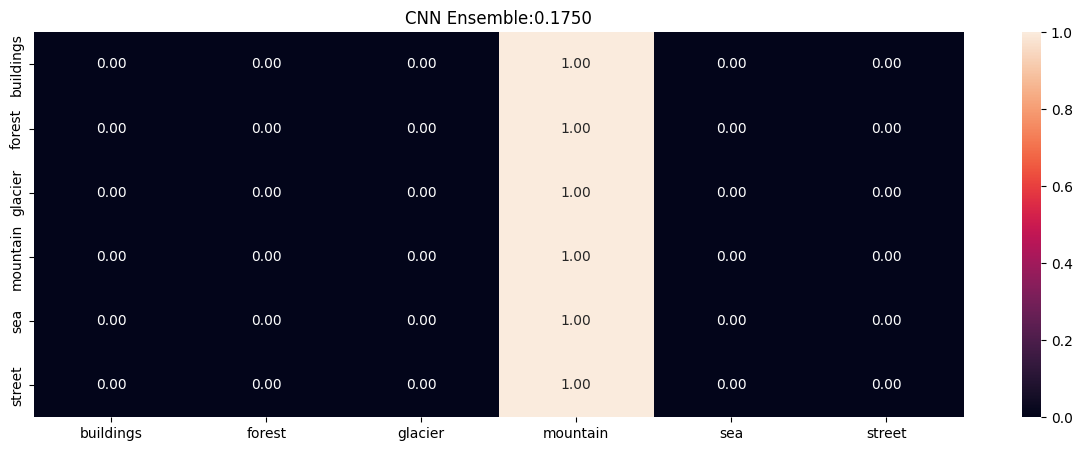

In [49]:
summarize_net(cnn_ens, X_test, y_test, title_text='CNN Ensemble:')

In [80]:
model = KerasClassifier(model=cnn_ens, epochs=5, batch_size=10, verbose=0)
my_scorer = make_scorer(accuracy_score)
results = cross_val_score(model, X_test, y_test_ohe, cv=sss, scoring=my_scorer)
print(results.mean())

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp4njvglqg\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmp4njvglqg\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpab78qjir\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpab78qjir\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmplkplp9l3\assets


...

INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpd2izk41l\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpd2izk41l\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpxg3ndmp0\assets


INFO:tensorflow:Assets written to: C:\Users\naimb\AppData\Local\Temp\tmpxg3ndmp0\assets


0.18453333333333335


## Comparing the performance of our convolutional network to a standard multi-layer perceptron (MLP)  

In [50]:
# make a keras MLP
mlp = Sequential()
mlp.add( Flatten() )
mlp.add( Dense(input_dim=X_train.shape[1], units=100, activation='relu') )
mlp.add( Dense(units=50, activation='relu') )
mlp.add( Dense(units=50, activation='relu') )
mlp.add( Dense(NUM_CLASSES) )
mlp.add( Activation('softmax') )

mlp.compile(loss='categorical_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

mlp.fit(X_train, y_train_ohe, 
        batch_size=32, epochs=15, 
        shuffle=True, verbose=1)

Epoch 1/15
439/439 [==============================] - 12s 24ms/step - loss: 268.1686 - accuracy: 0.1845
Epoch 2/15
439/439 [==============================] - 11s 24ms/step - loss: 1.8409 - accuracy: 0.1724
Epoch 3/15
439/439 [==============================] - 11s 24ms/step - loss: 1.8055 - accuracy: 0.1791
Epoch 4/15
439/439 [==============================] - 10s 24ms/step - loss: 1.7905 - accuracy: 0.1792
Epoch 5/15
439/439 [==============================] - 10s 24ms/step - loss: 1.8114 - accuracy: 0.1791
Epoch 6/15
439/439 [==============================] - 10s 24ms/step - loss: 1.7985 - accuracy: 0.1793
Epoch 7/15
439/439 [==============================] - 11s 24ms/step - loss: 1.7905 - accuracy: 0.1792
Epoch 8/15
439/439 [==============================] - 11s 24ms/step - loss: 1.7905 - accuracy: 0.1792
Epoch 9/15
439/439 [==============================] - 11s 24ms/step - loss: 1.7905 - accuracy: 0.1792
Epoch 10/15
439/439 [==============================] - 11s 24ms/step - loss: 1.7

In [51]:
def compare_mlp_cnn(cnn, mlp, X_test, y_test, labels='auto'):
    plt.figure(figsize=(15,5))
    if cnn is not None:
        yhat_cnn = np.argmax(cnn.predict(X_test), axis=1)
        acc_cnn = mt.accuracy_score(y_test,yhat_cnn)
        plt.subplot(1,2,1)
        cm = mt.confusion_matrix(y_test,yhat_cnn)
        cm = cm/np.sum(cm,axis=1)[:,np.newaxis]
        sns.heatmap(cm, annot=True, fmt='.2f',xticklabels=labels,yticklabels=labels)
        plt.title('CNN: '+str(acc_cnn))
    
    if mlp is not None:
        yhat_mlp = np.argmax(mlp.predict(X_test), axis=1)
        acc_mlp = mt.accuracy_score(y_test,yhat_mlp)
        plt.subplot(1,2,2)
        cm = mt.confusion_matrix(y_test,yhat_mlp)
        cm = cm/np.sum(cm,axis=1)[:,np.newaxis]
        sns.heatmap(cm,annot=True, fmt='.2f',xticklabels=labels,yticklabels=labels)
        plt.title('MLP: '+str(acc_mlp))

94/94 [==============================] - 1s 5ms/step


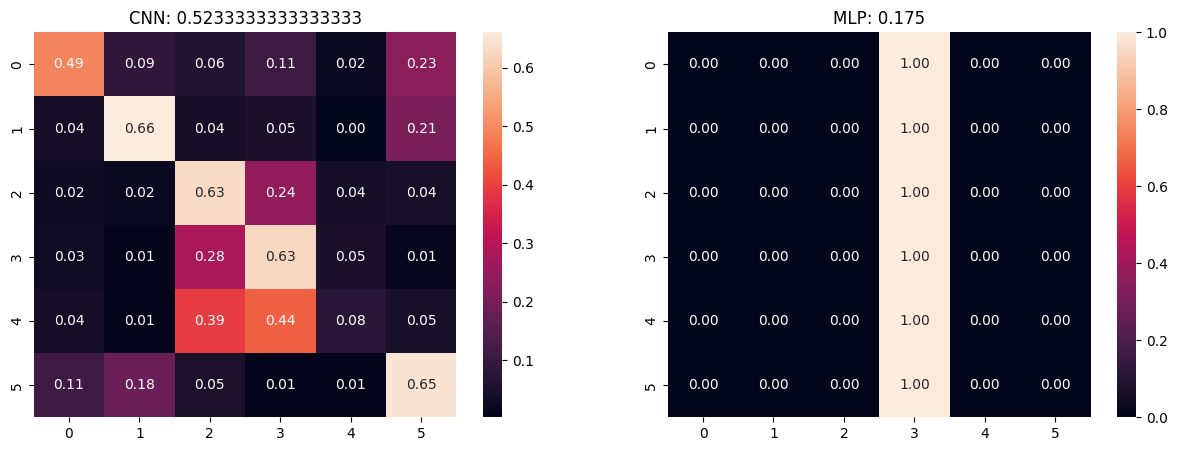

In [54]:
compare_mlp_cnn(cnn7,mlp,X_test,y_test)

# Exceptional Work

## One idea (required for 7000 level students): Use transfer learning to pre-train the weights of your initial layers of your CNN. Compare the performance when using transfer learning to training without transfer learning (i.e., compare to your best model from above) in terms of classification performance.

In [72]:
from tensorflow.keras.utils import to_categorical

y_train_ohe = to_categorical(y_train, NUM_CLASSES)
y_test_ohe = to_categorical(y_test, NUM_CLASSES)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(14034, 150, 150, 1)
(14034,)
(3000, 150, 150, 1)
(3000,)
